# Week 6 · Lab — Rigorous Benchmarking: the Grand Comparison

**Goals**
- Run SA, GA, PSO, ACO$_\mathbb{R}$, DE, CMA-ES and random search on a shifted–rotated test suite in $d=10$ under one
  evaluation budget and one protocol.
- Analyse the data in both views: **fixed budget** (error after $B$ evaluations) and **fixed target** (evaluations to
  reach an error), with the expected running time (ERT), runtime ECDFs (COCO style, Hansen et al. 2021) and performance
  profiles (Dolan & Moré 2002).
- Test differences with the Wilcoxon signed-rank test, the Friedman test with the Nemenyi post-hoc test and a
  critical-difference diagram (Demšar 2006), and Holm's correction — all implemented from scratch and validated against
  `scipy.stats` or exact identities.
- Close with a reproducibility checklist for metaheuristic papers.

**Prerequisites:** Notebooks 1–3 of this week (ask–tell algorithms, Friedman test); Week 1 (budgets, best-so-far traces).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import time
from utils import BENCHMARKS, shifted_rotated, random_rotation, PALETTE
from scipy import stats

## 1. Algorithms and protocol

The compact ask–tell implementations from Notebook 1 (copied so that the lab is self-contained). Every algorithm runs
with its default parameters — no per-function tuning, which would bias the comparison towards whoever tuned hardest.

In [2]:
# ---------------------------------------------------------------------------
# Ask-tell core: every algorithm is (memory M, ask = sample from P(.|M),
# tell = selection/acceptance + memory update). One generic loop drives all.
# ---------------------------------------------------------------------------
from utils import BudgetedObjective, BudgetExhausted


class AskTell:
    """Base class. Subclasses keep their memory in attributes and implement
    ask() -> (n, d) candidates and tell(X, y) -> None.
    `working_fitness()` returns the fitness values of the current working set
    (the states the next generation is derived from), used for diagnostics."""
    name = "base"

    def __init__(self, d, lo, hi, budget, rng):
        self.d, self.lo, self.hi, self.budget, self.rng = d, lo, hi, budget, rng
        self.span = (hi - lo) if lo is not None else 1.0
        self.n_told = 0

    def clip(self, X):
        return X if self.lo is None else np.clip(X, self.lo, self.hi)

    def uniform(self, n):
        return self.rng.uniform(self.lo, self.hi, (n, self.d))

    def progress(self):
        return min(1.0, self.n_told / self.budget)

    def working_fitness(self):
        return np.array([np.nan])


def distinct_indices(rng, n, k, n_pool=None, exclude=None):
    """For each row i < n: k distinct indices from range(n_pool), all different from i
    (and from exclude[i] if given), in uniformly random order (argsort of random keys)."""
    n_pool = n if n_pool is None else n_pool
    keys = rng.random((n, n_pool))
    keys[np.arange(n), np.arange(n)] = np.inf
    if exclude is not None:
        keys[np.arange(n), exclude] = np.inf
    return np.argsort(keys, axis=1)[:, :k]


def optimize(opt, f, budget, callback=None):
    """The single generic loop: ask -> evaluate (counted) -> tell.
    A final batch that would overrun the budget is truncated, so every
    algorithm spends exactly `budget` evaluations."""
    obj = BudgetedObjective(f, budget)
    while obj.remaining > 0:
        X = opt.ask()
        if len(X) > obj.remaining:
            obj(X[: obj.remaining])
            break
        y = obj(X)
        opt.tell(X, y)
        opt.n_told += len(y)
        if callback is not None:
            callback(opt, X, y, obj)
    return obj

class RandomSearch(AskTell):
    name = "RS"

    def ask(self):
        return self.uniform(20)

    def tell(self, X, y):
        pass

class SA(AskTell):
    """Simulated annealing: Gaussian proposal around the single current state,
    Metropolis acceptance; T and step size decay geometrically with the budget.
    T0 is calibrated so that the mean worsening seen in a short initial random
    walk is accepted with probability 1/2 (a common data-driven rule)."""
    name = "SA"

    def __init__(self, d, lo, hi, budget, rng, step0=0.1, step_end=1e-5, T_ratio=1e-8, n_cal=50, T0=None):
        super().__init__(d, lo, hi, budget, rng)
        self.x = self.uniform(1)[0] if lo is not None else rng.standard_normal(d)
        self.fx = None
        self.step0, self.step_end, self.T_ratio, self.n_cal = step0, step_end, T_ratio, n_cal
        self.T0 = T0
        self.cal = []
        self.log = []  # (delta, T, accepted) for worsening proposals

    def sched(self):
        p = self.progress()
        sig = self.span * self.step0 * (self.step_end / self.step0) ** p / np.sqrt(self.d)
        return sig, (self.T0 * self.T_ratio ** p if self.T0 is not None else np.inf)

    def ask(self):
        if self.fx is None:
            return self.x[None]
        sig, _ = self.sched()
        return self.clip(self.x + sig * self.rng.standard_normal(self.d))[None]

    def tell(self, X, y):
        if self.fx is None:
            self.fx = y[0]
            return
        delta = y[0] - self.fx
        if self.T0 is None:  # calibration random walk
            if delta > 0:
                self.cal.append(delta)
            self.x, self.fx = X[0], y[0]
            if len(self.cal) >= self.n_cal:
                self.T0 = np.mean(self.cal) / np.log(2.0)
            return
        _, T = self.sched()
        if delta <= 0:
            acc = True
        else:
            acc = self.rng.random() < np.exp(-delta / T)
            self.log.append((delta, T, acc))
        if acc:
            self.x, self.fx = X[0], y[0]

    def working_fitness(self):
        return np.array([self.fx if self.fx is not None else np.nan])

class TS(AskTell):
    """Continuous tabu search: sample k Gaussian neighbours, forbid those within
    radius rho of the last L visited states (tabu list = short-term memory),
    move to the best admissible neighbour even if it is worse; aspiration:
    a tabu neighbour is admissible if it beats the best-so-far."""
    name = "TS"

    def __init__(self, d, lo, hi, budget, rng, k=8, L=20, step0=0.1, step_end=1e-5, rho_factor=0.5):
        super().__init__(d, lo, hi, budget, rng)
        self.x = self.uniform(1)[0] if lo is not None else rng.standard_normal(d)
        self.fx, self.k, self.L = None, k, L
        self.step0, self.step_end, self.rho_factor = step0, step_end, rho_factor
        self.tabu = []
        self.best = np.inf
        self.log = []  # (distance to tabu list, rho, new best?, fallback?, worsening?)

    def sigma(self):
        p = self.progress()
        return self.span * self.step0 * (self.step_end / self.step0) ** p / np.sqrt(self.d)

    def ask(self):
        if self.fx is None:
            return self.x[None]
        return self.clip(self.x + self.sigma() * self.rng.standard_normal((self.k, self.d)))

    def tell(self, X, y):
        if self.fx is None:
            self.fx = self.best = y[0]
            self.tabu.append(self.x.copy())
            return
        sig = self.sigma()
        rho = self.rho_factor * sig * np.sqrt(self.d)
        T = np.array(self.tabu)
        dist = np.sqrt(((X[:, None, :] - T[None]) ** 2).sum(-1)).min(1)
        admissible = (dist >= rho) | (y < self.best)
        fallback = not admissible.any()
        if fallback:  # every neighbour tabu and none aspirated: take the best one anyway
            admissible[:] = True
        idx = np.flatnonzero(admissible)
        j = idx[np.argmin(y[idx])]
        self.log.append((dist[j], rho, y[j] < self.best, fallback, y[j] > self.fx))
        self.x, self.fx = X[j].copy(), y[j]
        self.best = min(self.best, y[j])
        self.tabu.append(self.x.copy())
        self.tabu = self.tabu[-self.L:]

    def working_fitness(self):
        return np.array([self.fx if self.fx is not None else np.nan])

def sbx_pm(P1, P2, lo, hi, rng, pc=0.9, eta_c=15.0, pm=None, eta_m=20.0):
    """Simulated binary crossover (Deb & Agrawal 1995) + polynomial mutation
    (Deb & Goyal 1996), vectorised over pairs; box [lo, hi]."""
    n, d = P1.shape
    pm = 1.0 / d if pm is None else pm
    u = rng.random((n, d))
    beta = np.where(u <= 0.5, (2 * u) ** (1 / (eta_c + 1)), (1 / (2 * (1 - u))) ** (1 / (eta_c + 1)))
    cross = (rng.random((n, 1)) < pc) & (rng.random((n, d)) < 0.5)
    beta = np.where(cross, beta, 1.0)
    C1 = 0.5 * ((1 + beta) * P1 + (1 - beta) * P2)
    C2 = 0.5 * ((1 - beta) * P1 + (1 + beta) * P2)
    swap = cross & (rng.random((n, d)) < 0.5)  # exchange crossed variables w.p. 1/2 (as in Deb's code)
    C = np.vstack([np.where(swap, C2, C1), np.where(swap, C1, C2)])
    u = rng.random(C.shape)
    delta = np.where(u < 0.5, (2 * u) ** (1 / (eta_m + 1)) - 1, 1 - (2 * (1 - u)) ** (1 / (eta_m + 1)))
    mut = rng.random(C.shape) < pm
    C = C + mut * delta * (hi - lo)
    return np.clip(C, lo, hi)


class GA(AskTell):
    """Real-coded generational GA: binary tournament selection, SBX crossover,
    polynomial mutation, elitism of size 1."""
    name = "GA"

    def __init__(self, d, lo, hi, budget, rng, n=50, pc=0.9, pm=None, tour=2):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.pc, self.pm, self.tour = n, pc, pm, tour
        self.P, self.fP = None, None

    def select(self, k):
        c = self.rng.integers(0, self.n, (k, self.tour))
        return c[np.arange(k), np.argmin(self.fP[c], axis=1)]

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        m = self.n // 2 + 1
        a, b = self.select(m), self.select(m)
        C = sbx_pm(self.P[a], self.P[b], self.lo, self.hi, self.rng, pc=self.pc, pm=self.pm)
        return C[: self.n - 1]

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        e = np.argmin(self.fP)
        self.P = np.vstack([self.P[e], X])
        self.fP = np.concatenate([[self.fP[e]], y])

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

class PSO(AskTell):
    """Global-best PSO with inertia weight (Shi & Eberhart 1998); defaults
    w = 0.7298, c1 = c2 = 1.49618 are Clerc & Kennedy's (2002) constriction
    coefficients rewritten in inertia form. Velocity clamped to vmax."""
    name = "PSO"

    def __init__(self, d, lo, hi, budget, rng, n=40, w=0.7298, c1=1.49618, c2=1.49618, vmax=0.2):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.w, self.c1, self.c2 = n, w, c1, c2
        self.vmax = vmax * self.span
        self.X = self.uniform(n)
        self.V = rng.uniform(-1, 1, (n, d)) * 0.1 * self.span
        self.Pb, self.fPb, self.fX = None, None, None

    def ask(self):
        if self.Pb is None:
            return self.X
        g = self.Pb[np.argmin(self.fPb)]
        r1, r2 = self.rng.random((2, self.n, self.d))
        self.V = self.w * self.V + self.c1 * r1 * (self.Pb - self.X) + self.c2 * r2 * (g - self.X)
        self.V = np.clip(self.V, -self.vmax, self.vmax)
        self.X = self.clip(self.X + self.V)
        return self.X

    def tell(self, X, y):
        if self.Pb is None:
            self.Pb, self.fPb = X.copy(), y.copy()
        else:
            imp = y < self.fPb
            self.Pb[imp], self.fPb[imp] = X[imp], y[imp]
        self.fX = y.copy()

    def working_fitness(self):
        return self.fX if self.fX is not None else np.array([np.nan])

class ACOR(AskTell):
    """ACO for continuous domains (Socha & Dorigo 2008). Memory = archive of the
    k best solutions (the 'pheromone'); each ant picks a guide solution l with
    probability proportional to a Gaussian rank weight and samples each
    coordinate from N(s_l, sigma_l), sigma_l = xi * mean |s_e - s_l|."""
    name = "ACO_R"

    def __init__(self, d, lo, hi, budget, rng, k=50, m=2, q=0.1, xi=0.85):
        super().__init__(d, lo, hi, budget, rng)
        self.k, self.m, self.q, self.xi = k, m, q, xi
        r = np.arange(1, k + 1)
        w = np.exp(-((r - 1) ** 2) / (2 * (q * k) ** 2)) / (q * k * np.sqrt(2 * np.pi))
        self.p = w / w.sum()
        self.cdf = np.cumsum(self.p)
        self.S, self.fS = None, None
        self.last_guides = None

    def ask(self):
        if self.S is None:
            return self.uniform(self.k)
        l = np.minimum(np.searchsorted(self.cdf, self.rng.random(self.m)), self.k - 1)
        self.last_guides = l
        sig = self.xi * np.abs(self.S[None, :, :] - self.S[l][:, None, :]).sum(1) / (self.k - 1)
        return self.clip(self.S[l] + sig * self.rng.standard_normal((self.m, self.d)))

    def tell(self, X, y):
        S = X if self.S is None else np.vstack([self.S, X])
        fS = y if self.fS is None else np.concatenate([self.fS, y])
        o = np.argsort(fS, kind="stable")[: self.k]
        self.S, self.fS = S[o], fS[o]

    def working_fitness(self):
        return self.fS if self.fS is not None else np.array([np.nan])

class DE(AskTell):
    """DE/rand/1/bin (Storn & Price 1997) with one-to-one greedy replacement."""
    name = "DE"

    def __init__(self, d, lo, hi, budget, rng, n=50, F=0.5, CR=0.9):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.F, self.CR = n, F, CR
        self.P, self.fP = None, None

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        n, d = self.n, self.d
        idx = distinct_indices(self.rng, n, 3)
        V = self.P[idx[:, 0]] + self.F * (self.P[idx[:, 1]] - self.P[idx[:, 2]])
        mask = self.rng.random((n, d)) < self.CR
        mask[np.arange(n), self.rng.integers(0, d, n)] = True
        self.mask = mask
        return self.clip(np.where(mask, V, self.P))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        imp = y <= self.fP
        self.P[imp], self.fP[imp] = X[imp], y[imp]

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

class CMAES(AskTell):
    """(mu/mu_w, lambda)-CMA-ES with the default strategy parameters of Hansen's
    tutorial (arXiv:1604.00772v1, 2016, Table 1): weighted recombination, cumulative
    step-size adaptation (CSA), rank-one + rank-mu covariance update.
    Deviation: only the mu positive weights are used (w_i = 0 for i > mu), as in
    the tutorial's reference code (Appendix C); Table 1's default also has negative
    weights ("active" CMA). All other constants (c_sigma, d_sigma, c_c, c_1, c_mu,
    h_sigma) are exactly the formulas of the 2016 tutorial."""
    name = "CMA-ES"

    def __init__(self, d, lo, hi, budget, rng, m0=None, sigma0=0.3, lam=None):
        super().__init__(d, lo, hi, budget, rng)
        n = d
        self.m = (self.uniform(1)[0] if lo is not None else np.zeros(n)) if m0 is None else np.array(m0, float)
        self.sigma = sigma0 * self.span
        self.lam = lam or 4 + int(3 * np.log(n))
        self.mu = self.lam // 2
        wp = np.log((self.lam + 1) / 2) - np.log(np.arange(1, self.mu + 1))
        self.w = wp / wp.sum()
        self.mueff = 1 / np.sum(self.w**2)
        self.cs = (self.mueff + 2) / (n + self.mueff + 5)
        self.ds = 1 + 2 * max(0, np.sqrt((self.mueff - 1) / (n + 1)) - 1) + self.cs
        self.cc = (4 + self.mueff / n) / (n + 4 + 2 * self.mueff / n)
        self.c1 = 2 / ((n + 1.3) ** 2 + self.mueff)
        self.cmu = min(1 - self.c1, 2 * (self.mueff - 2 + 1 / self.mueff) / ((n + 2) ** 2 + self.mueff))
        self.chiN = np.sqrt(n) * (1 - 1 / (4 * n) + 1 / (21 * n**2))
        self.ps, self.pc = np.zeros(n), np.zeros(n)
        self.C, self.B, self.D = np.eye(n), np.eye(n), np.ones(n)
        self.g = 0
        self.fX = None

    def ask(self):
        Z = self.rng.standard_normal((self.lam, self.d))
        return self.clip(self.m + self.sigma * (Z * self.D) @ self.B.T)

    def tell(self, X, y):
        n = self.d
        o = np.argsort(y)
        Y = (X[o[: self.mu]] - self.m) / self.sigma
        yw = self.w @ Y
        self.m = self.m + self.sigma * yw
        Cinvsqrt = (self.B / self.D) @ self.B.T
        self.ps = (1 - self.cs) * self.ps + np.sqrt(self.cs * (2 - self.cs) * self.mueff) * Cinvsqrt @ yw
        self.g += 1
        hs = np.linalg.norm(self.ps) / np.sqrt(1 - (1 - self.cs) ** (2 * self.g)) < (1.4 + 2 / (n + 1)) * self.chiN
        self.pc = (1 - self.cc) * self.pc + hs * np.sqrt(self.cc * (2 - self.cc) * self.mueff) * yw
        dh = (1 - hs) * self.cc * (2 - self.cc)
        self.C = ((1 - self.c1 - self.cmu + self.c1 * dh) * self.C + self.c1 * np.outer(self.pc, self.pc)
                  + self.cmu * (Y.T * self.w) @ Y)
        self.sigma *= np.exp(self.cs / self.ds * (np.linalg.norm(self.ps) / self.chiN - 1))
        self.C = (self.C + self.C.T) / 2
        ev, self.B = np.linalg.eigh(self.C)
        self.D = np.sqrt(np.maximum(ev, 1e-30))
        self.fX = y.copy()

    def working_fitness(self):
        return self.fX if self.fX is not None else np.array([np.nan])

**Protocol (fixed before looking at any result).**

| item | choice |
|---|---|
| functions | sphere, ellipsoid (cond. $10^6$), Rosenbrock, Rastrigin, Ackley, Lévy — each composed as $f(R(x-o))$ |
| instances | 5 per function: instance $s$ draws its own shift $o$ (optimum inside the box) and Haar rotation $R$ from seed $s$ |
| dimension, box | $d=10$, the function's standard box; out-of-box samples are clipped (same rule for all) |
| budget | $B=500\,d=5000$ evaluations per run, one run per (algorithm, instance) |
| measured | full best-so-far trace of $f-f^{\ast}$ ($f^{\ast}=0$ is preserved by the transformation) |
| targets | 51 log-uniform targets $10^{2},10^{1.8},\dots,10^{-8}$ (COCO) |

**Honest limits.** COCO uses budgets of $10^5d$ or more, 15 instances and several dimensions; we use $500d$ and 5
instances to keep the notebook under 90 s. Conclusions below are therefore about the *small-budget* regime in $d=10$
only; in particular algorithms that are slow starters (DE with its population of $N=50$) are penalised.

In [3]:
d, B, n_inst = 10, 5000, 5
fnames = ["sphere", "ellipsoid", "rosenbrock", "rastrigin", "ackley", "levy"]
algs = [RandomSearch, SA, GA, PSO, ACOR, DE, CMAES]
names = [A.name for A in algs]

def make_instance(fn, s):
    b = BENCHMARKS[fn]; r = np.random.default_rng(10_000 + 97 * s + len(fn))
    R = random_rotation(d, r)
    if fn in ("rosenbrock", "levy"):        # optimum of the base function is at 1: place it at a random point o'
        target = r.uniform(0.5 * b.lower, 0.5 * b.upper, d) if fn == "levy" else r.uniform(-2, 2, d)
        o = target - R.T @ np.ones(d)       # f(R(x - o)) is optimal where R(x - o) = 1
    else:
        o = r.uniform(0.6 * b.lower, 0.6 * b.upper, d)
    return shifted_rotated(b.f, o, R), b.lower, b.upper

traces = {}   # (alg, fn, s) -> (evals, best-so-far error)
t0 = time.time()
for fn in fnames:
    for s in range(n_inst):
        f, lo, hi = make_instance(fn, s)
        for A in algs:
            obj = optimize(A(d, lo, hi, B, np.random.default_rng(s)), f, B)
            traces[A.name, fn, s] = obj.trace()
print(f"{len(traces)} runs x {B} evaluations in {time.time() - t0:.1f} s")
check_true(all(len(v[0]) == B and v[0][-1] == B for v in traces.values()), "every run used exactly the budget")
check_true(all(np.all(np.diff(v[1]) <= 0) for v in traces.values()), "all best-so-far traces are monotone")

210 runs x 5000 evaluations in 17.5 s
[PASS] every run used exactly the budget
[PASS] all best-so-far traces are monotone


## 2. Fixed-budget view

A *vertical cut* through the convergence graphs: the error reached after $b$ evaluations. Easy to read but the values
are on an ordinal scale only — "error $10^{-3}$ vs $10^{-6}$" does not say how much *better* one algorithm is, and the
answer depends on the chosen $b$.

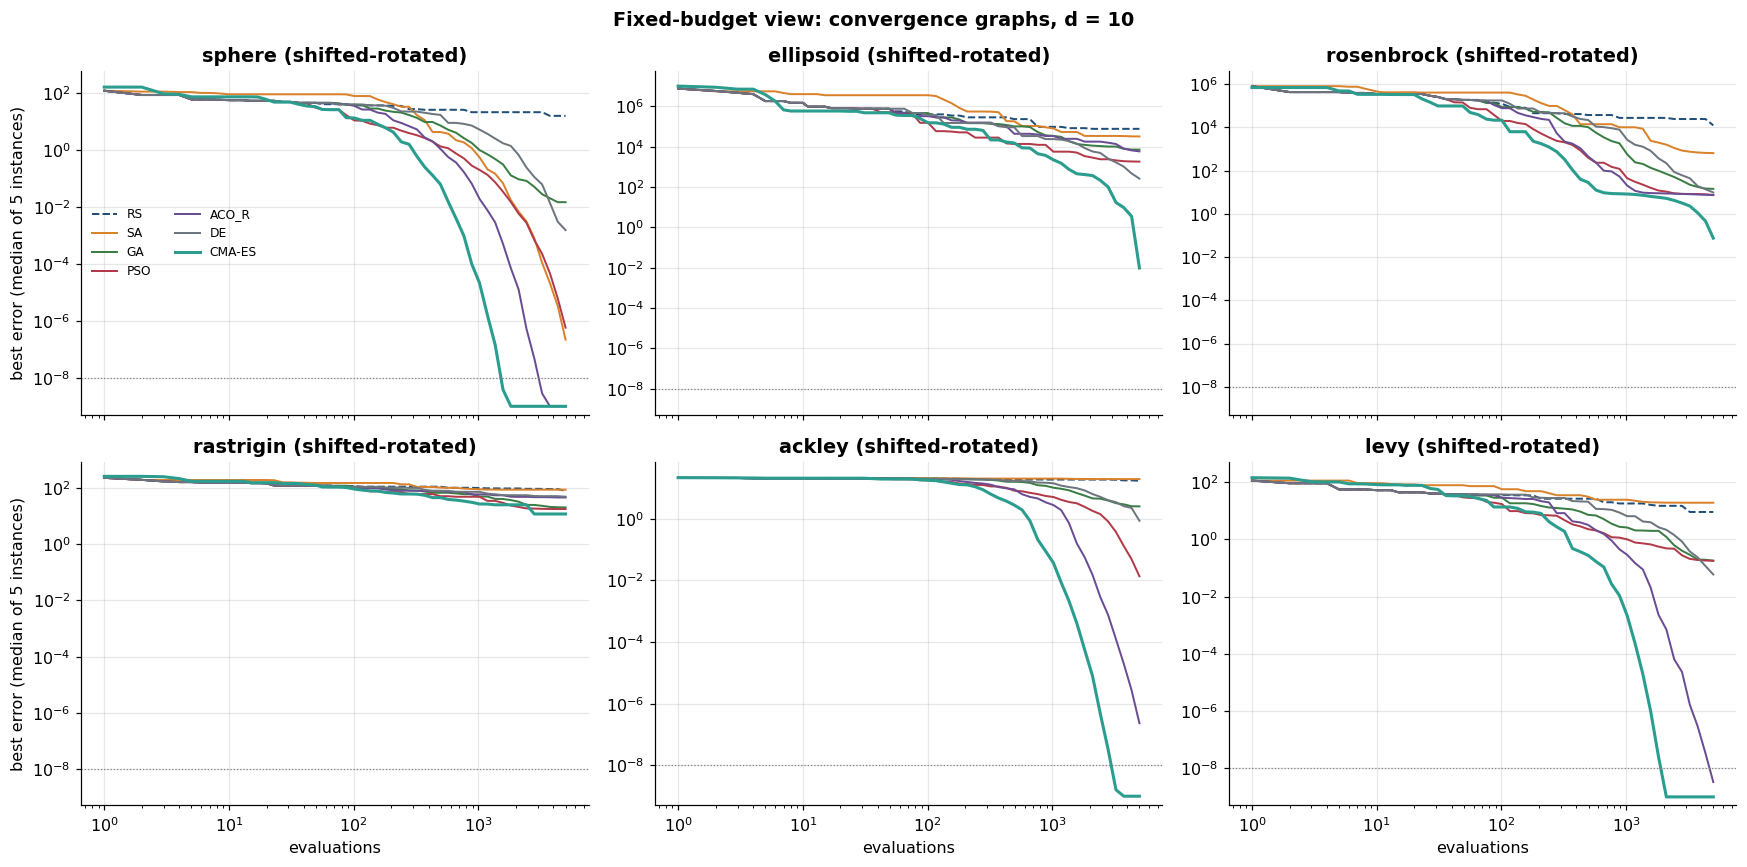

median final error (floored at the final target 1e-8):
                   RS        SA        GA       PSO     ACO_R        DE    CMA-ES
sphere        1.6e+01   2.2e-07   1.5e-02   5.8e-07   1.0e-08   1.5e-03   1.0e-08
ellipsoid     7.7e+04   3.2e+04   7.2e+03   1.8e+03   5.8e+03   2.6e+02   9.6e-03
rosenbrock    1.3e+04   6.5e+02   1.4e+01   7.6e+00   7.4e+00   9.8e+00   7.6e-02
rastrigin     7.9e+01   8.8e+01   2.0e+01   1.8e+01   4.6e+01   4.9e+01   1.2e+01
ackley        1.7e+01   1.9e+01   2.5e+00   1.4e-02   2.3e-07   8.7e-01   1.0e-08
levy          9.1e+00   1.9e+01   1.8e-01   1.8e-01   1.0e-08   5.9e-02   1.0e-08


In [4]:
grid = np.unique(np.geomspace(1, B, 60).astype(int))
def on_grid(ev, fb, grid):
    idx = np.searchsorted(ev, grid, side="right") - 1
    return np.where(idx >= 0, fb[np.maximum(idx, 0)], np.nan)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, fn in zip(axes.ravel(), fnames):
    for n in names:
        C = np.array([on_grid(*traces[n, fn, s], grid) for s in range(n_inst)])
        C = np.maximum(C, 1e-9)
        ax.plot(grid, np.median(C, 0), label=n, lw=2 if n == "CMA-ES" else 1.3, ls="--" if n == "RS" else "-")
    ax.axhline(1e-8, color="grey", lw=0.8, ls=":")
    ax.set(xscale="log", yscale="log", title=f"{fn} (shifted-rotated)", ylim=(5e-10, None))
for ax in axes[1]: ax.set_xlabel("evaluations")
for ax in axes[:, 0]: ax.set_ylabel("best error (median of 5 instances)")
axes[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle("Fixed-budget view: convergence graphs, d = 10", fontweight="bold")
plt.tight_layout(); savefig("w6_lab_convergence.png"); plt.show()

final = {(n, fn, s): max(traces[n, fn, s][1][-1], 1e-8) for n in names for fn in fnames for s in range(n_inst)}
print("median final error (floored at the final target 1e-8):")
print(f"{'':11s}" + "".join(f"{n:>10s}" for n in names))
for fn in fnames:
    print(f"{fn:11s}" + "".join(f"{np.median([final[n, fn, s] for s in range(n_inst)]):10.1e}" for n in names))

## 3. Fixed-target view: ERT, runtime ECDFs, performance profiles

A *horizontal cut*: the number of evaluations $T$ needed to reach $f-f^{\ast}\le\Delta f_t$. Runtimes live on a
**ratio scale** ("CMA-ES needs 5× fewer evaluations") — the main reason COCO prefers this view (Hansen et al. 2021,
2022). Unsuccessful runs are right-censored at $B$.

**Expected running time** (Price 1997; Auger & Hansen 2005): with $n_s$ successful runs among $n$,

$$
\mathrm{ERT}(\Delta f_t) = \frac{\sum_{\text{runs}}\min(T_i, B)}{n_s} = \overline{T}_{\text{succ}} + \frac{1-p_s}{p_s}\,\overline{T}_{\text{unsucc}}.
$$

It estimates the expected number of evaluations of an algorithm *restarted independently until success*. **Exact check:**
if every evaluation succeeds independently with probability $p$ (a geometric runtime), then
$\mathbb{E}[\min(T,B)] = (1-(1-p)^B)/p$ and $\Pr[T\le B]=1-(1-p)^B$, so ERT is a consistent estimator of exactly $1/p$
for any budget $B$ — even $B\ll1/p$.

In [5]:
def runtime(ev, fb, target):
    """First evaluation at which best-so-far error <= target; np.inf if never."""
    hit = np.flatnonzero(fb <= target)
    return ev[hit[0]] if len(hit) else np.inf

def ert(runtimes, budget):
    rt = np.asarray(runtimes, float); succ = np.isfinite(rt)
    return np.inf if succ.sum() == 0 else np.minimum(rt, budget).sum() / succ.sum()

def ert_se(runtimes, budget):
    """Delta-method standard error of ERT = sum(min(T_i, B)) / sum(1[success_i]) (a ratio of sums)."""
    rt = np.asarray(runtimes, float); succ = np.isfinite(rt); e = ert(rt, budget)
    z = np.minimum(rt, budget) - e * succ
    return np.sqrt(len(rt) * z.var()) / succ.sum()

# validation: random search on a "needle" of probability mass p -> geometric runtimes, ERT -> 1/p
p_needle = 0.004
needle = lambda X: np.where(np.atleast_2d(X)[:, 0] < -1 + 2 * p_needle, 0.0, 1.0)
for B_small in [100, 2000]:
    rts = []
    for s in range(3000):
        obj = optimize(RandomSearch(2, -1.0, 1.0, B_small, np.random.default_rng(s)), needle, B_small)
        rts.append(runtime(*obj.trace(), 0.0))
    se = ert_se(rts, B_small)
    check_close(ert(rts, B_small), 1 / p_needle, f"ERT of random search on a needle (p = {p_needle}, budget {B_small}) vs 1/p "
                f"(tolerance 4 SE = {4 * se:.1f})", atol=4 * se, rtol=0)

targets = 10.0 ** np.arange(2, -8.01, -0.2)
RT = {(n, fn): np.array([[runtime(*traces[n, fn, s], t) for t in targets] for s in range(n_inst)]) for n in names for fn in fnames}
ERT = {(n, fn): np.array([ert(RT[n, fn][:, j], B) for j in range(len(targets))]) for n in names for fn in fnames}
print("ERT / d to reach 1e-1 and 1e-8 (inf = never within budget):")
j1, j8 = np.argmin(np.abs(targets - 1e-1)), len(targets) - 1
for fn in fnames:
    print(f"  {fn:11s}" + "".join(f"{n}: {ERT[n, fn][j1] / d:7.0f}/{ERT[n, fn][j8] / d:<7.0f}" for n in ["PSO", "DE", "CMA-ES"]))

[PASS] ERT of random search on a needle (p = 0.004, budget 100) vs 1/p (tolerance 4 SE = 33.6): got 260.330199, expected 250.0


[PASS] ERT of random search on a needle (p = 0.004, budget 2000) vs 1/p (tolerance 4 SE = 18.0): got 251.893298, expected 250.0
ERT / d to reach 1e-1 and 1e-8 (inf = never within budget):
  sphere     PSO:     128/inf    DE:     288/inf    CMA-ES:      45/153    
  ellipsoid  PSO:     inf/inf    DE:     inf/inf    CMA-ES:     571/inf    
  rosenbrock PSO:     inf/inf    DE:     inf/inf    CMA-ES:     794/inf    
  rastrigin  PSO:     inf/inf    DE:     inf/inf    CMA-ES:     inf/inf    
  ackley     PSO:     707/inf    DE:     inf/inf    CMA-ES:      87/294    
  levy       PSO:     967/inf    DE:     559/inf    CMA-ES:      64/306    


**Runtime ECDF.** For each algorithm, pool all (function, instance, target) triples; the ECDF at $t$ is the fraction of
triples whose target was reached within $t$ evaluations. It is the empirical cumulative distribution of the runtime of
the combined task "solve a random (function, target)", and its area (with log-scaled $t$) summarises the whole
convergence graph — anytime performance in one curve. Because of the censoring, ECDFs are only defined up to $B$.

**Performance profile** (Dolan & Moré 2002). For problem $p$ (here: a (function, target) pair with targets
$10^{1},10^{-1},10^{-3},10^{-5},10^{-8}$) and solver $s$ with cost $t_{p,s}$ (ERT; $\infty$ if never solved), the ratio
$r_{p,s}=t_{p,s}/\min_{s'}t_{p,s'}$ and $\rho_s(\tau)=\frac{1}{\lvert P\rvert}\lvert\lbrace p:r_{p,s}\le\tau\rbrace\rvert$.
$\rho_s(1)$ is the fraction of problems on which $s$ is (one of) the fastest; $\lim_{\tau\to\infty}\rho_s(\tau)$ the fraction
it solves at all. Problems solved by nobody are removed.

In [6]:
tgrid = np.unique(np.geomspace(1, B, 200).astype(int))
ecdf = {}
for n in names:
    allrt = np.concatenate([RT[n, fn].ravel() for fn in fnames])
    ecdf[n] = np.array([np.mean(allrt <= t) for t in tgrid])
    # independent computation of the final value from the final errors
    frac_final = np.mean([final_err <= t for fn in fnames for s in range(n_inst)
                          for final_err in [traces[n, fn, s][1][-1]] for t in targets])
    check_close(ecdf[n][-1], frac_final, f"{n}: ECDF at budget = fraction of (run, target) pairs solved by the final error")
check_true(all(np.all(np.diff(e) >= 0) for e in ecdf.values()), "ECDFs are non-decreasing")

def performance_profile(cost, taus):
    """cost: (problems, solvers), np.inf = unsolved. Returns rho[s, t] = share of problems with ratio <= taus[t]."""
    ratios = cost / cost.min(1, keepdims=True)
    return np.array([[np.mean(ratios[:, i] <= t) for t in taus] for i in range(cost.shape[1])])

# hand-computed example: 3 problems x 3 solvers (ties and an unsolved problem included)
toy = np.array([[1.0, 2.0, np.inf], [3.0, 3.0, 6.0], [10.0, 5.0, 5.0]])
check_close(performance_profile(toy, [1.0, 2.0, 1e9]), [[2 / 3, 1.0, 1.0], [2 / 3, 1.0, 1.0], [1 / 3, 2 / 3, 2 / 3]],
            "performance profile of a hand-computed 3 x 3 example (rho at tau = 1, 2, infinity)")

pp_targets = [1e1, 1e-1, 1e-3, 1e-5, 1e-8]
cost = np.array([[ERT[n, fn][np.argmin(np.abs(targets - t))] for n in names] for fn in fnames for t in pp_targets])
solved_by_someone = np.isfinite(cost).any(1)
cost = cost[solved_by_someone]
taus = np.geomspace(1, 1e3, 300)
rho = dict(zip(names, performance_profile(cost, taus)))
n_best = np.array([np.sum(cost[:, i] == cost.min(1)) for i in range(len(names))])
check_close([rho[n][0] for n in names], n_best / len(cost), "performance profile rho_s(1) = share of problems where s is fastest")
print(f"{len(cost)} (function, target) problems solved by at least one algorithm; rho_s(1):",
      dict(zip(names, np.round([rho[n][0] for n in names], 2).tolist())))

[PASS] RS: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.04902, expected 0.04902
[PASS] SA: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.188235, expected 0.188235
[PASS] GA: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.164052, expected 0.164052
[PASS] PSO: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.278431, expected 0.278431
[PASS] ACO_R: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.500654, expected 0.500654
[PASS] DE: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.198039, expected 0.198039
[PASS] CMA-ES: ECDF at budget = fraction of (run, target) pairs solved by the final error: got 0.622222, expected 0.622222
[PASS] ECDFs are non-decreasing
[PASS] performance profile of a hand-computed 3 x 3 example (rho at tau = 1, 2, infinity): got [[0.666667 1.       1.      ]
 [0.

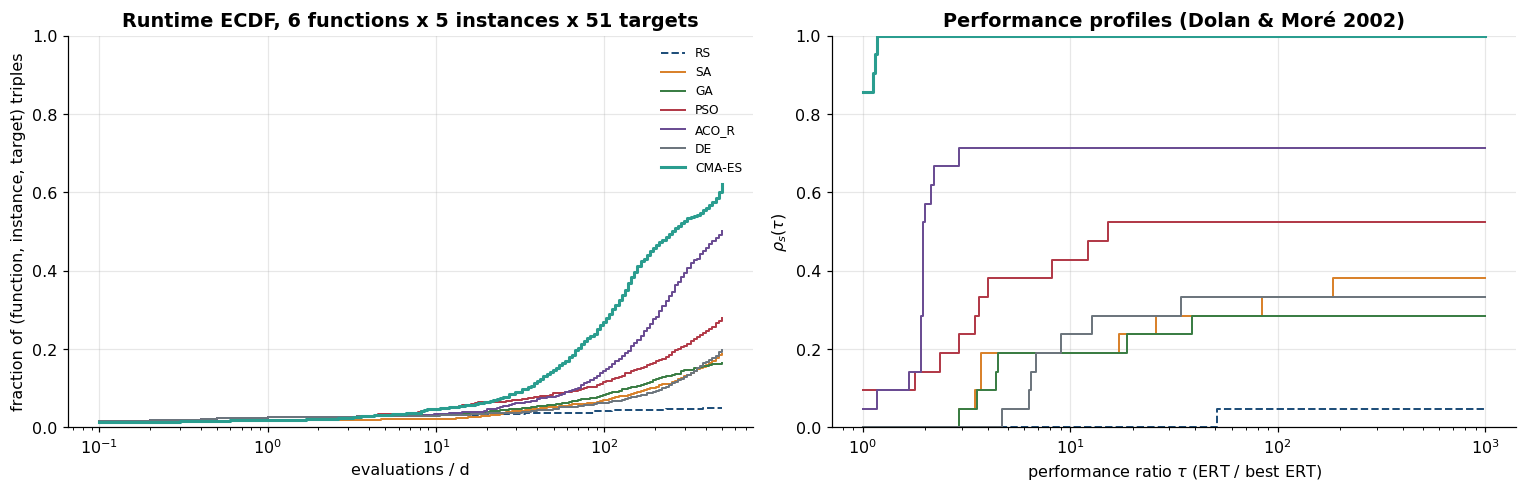

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for n in names:
    axes[0].step(tgrid / d, ecdf[n], where="post", label=n, lw=2 if n == "CMA-ES" else 1.3, ls="--" if n == "RS" else "-")
    axes[1].step(taus, rho[n], where="post", label=n, lw=2 if n == "CMA-ES" else 1.3, ls="--" if n == "RS" else "-")
axes[0].set(xscale="log", xlabel="evaluations / d", ylabel="fraction of (function, instance, target) triples",
            title="Runtime ECDF, 6 functions x 5 instances x 51 targets", ylim=(0, 1))
axes[1].set(xscale="log", xlabel=r"performance ratio $\tau$ (ERT / best ERT)", ylabel=r"$\rho_s(\tau)$",
            title="Performance profiles (Dolan & Moré 2002)", ylim=(0, 1))
axes[0].legend(fontsize=8); plt.tight_layout(); savefig("w6_lab_ecdf_profiles.png"); plt.show()

## 4. Statistical testing

**Unit of analysis.** A *block* is one (function, instance) pair; every algorithm has one run per block (a complete
block design with $N=30$ blocks, $k=7$ treatments). The response is the final error floored at $10^{-8}$, so runs that
reach the final target tie. Demšar (2006) recommends: Friedman test over all $k$; if it rejects, the Nemenyi test
(all pairs) with a critical-difference (CD) diagram, or comparisons with a control using Holm's procedure; for two
algorithms, the Wilcoxon signed-rank test.

### 4.1 Wilcoxon signed-rank test (own implementation)
Differences $D_i=x_i-y_i$, zeros discarded (Wilcoxon's convention), ranks $r_i$ of $\lvert D_i\rvert$ (average ranks for
ties), $W^{+}=\sum_{D_i\gt0}r_i$, statistic $T=\min(W^{+},W^{-})$. **Exact null** (no ties): each rank carries a sign
$\pm$ with probability $1/2$ independently, so the number of sign patterns with $W^{+}=w$ is the number of subsets of
$\lbrace1,\dots,n\rbrace$ summing to $w$, computed by dynamic programming; $p=\min(1,2\Pr[W^{+}\le T])$. **Normal
approximation** (ties): $\mathbb{E}W^{+}=n(n+1)/4$, $\mathrm{Var}W^{+}=n(n+1)(2n+1)/24-\sum(t^3-t)/48$.

In [8]:
def average_ranks(v):
    order = np.argsort(v, kind="mergesort"); ranks = np.empty(len(v)); sv = np.asarray(v)[order]; i = 0
    while i < len(v):
        j = i
        while j + 1 < len(v) and sv[j + 1] == sv[i]: j += 1
        ranks[order[i:j + 1]] = 0.5 * (i + j) + 1; i = j + 1
    return ranks

def wilcoxon_signed_rank(x, y, method="auto"):
    D = np.asarray(x, float) - np.asarray(y, float); D = D[D != 0]; n = len(D)
    r = average_ranks(np.abs(D)); Wp = r[D > 0].sum(); Wm = r[D < 0].sum(); T = min(Wp, Wm)
    ties = len(np.unique(np.abs(D))) < n
    if method == "exact" or (method == "auto" and n <= 50 and not ties):
        counts = np.zeros(n * (n + 1) // 2 + 1); counts[0] = 1
        for k in range(1, n + 1):                   # subsets of {1..k}: include k or not
            counts[k:] = counts[k:] + counts[:-k].copy()
        cdf = np.cumsum(counts) / 2.0**n
        return T, min(1.0, 2 * cdf[int(np.floor(T))])
    _, t_counts = np.unique(np.abs(D), return_counts=True)
    var = n * (n + 1) * (2 * n + 1) / 24 - np.sum(t_counts**3 - t_counts) / 48
    z = (T - n * (n + 1) / 4) / np.sqrt(var)
    return T, min(1.0, 2 * stats.norm.cdf(z))

r_v = np.random.default_rng(5)
for n_w in [8, 15, 30]:
    x = r_v.normal(0.4, 1, n_w); y = r_v.normal(0, 1, n_w)
    ref = stats.wilcoxon(x, y, method="exact")
    check_close(wilcoxon_signed_rank(x, y, "exact"), [ref.statistic, ref.pvalue], f"Wilcoxon exact vs scipy (n={n_w})")
xt = np.round(r_v.normal(0.5, 1, 40), 1); yt = np.round(r_v.normal(0, 1, 40), 1)   # ties and zeros
ref = stats.wilcoxon(xt, yt, method="asymptotic", correction=False)
check_close(wilcoxon_signed_rank(xt, yt, "asymptotic"), [ref.statistic, ref.pvalue], "Wilcoxon normal approximation with ties/zeros vs scipy")

[PASS] Wilcoxon exact vs scipy (n=8): got [18.  1.], expected [18.  1.]
[PASS] Wilcoxon exact vs scipy (n=15): got [39.       0.25238], expected [39.       0.25238]
[PASS] Wilcoxon exact vs scipy (n=30): got [6.40e+01 2.56e-04], expected [6.40e+01 2.56e-04]
[PASS] Wilcoxon normal approximation with ties/zeros vs scipy: got [2.3450e+02 2.9981e-02], expected [2.3450e+02 2.9981e-02]


### 4.2 Friedman, Nemenyi, Holm
Friedman as in Notebook 3 (validated again below). **Nemenyi** (1963): two algorithms differ if their average ranks
differ by at least $\mathrm{CD}=q_\alpha\sqrt{k(k+1)/(6N)}$, where $q_\alpha$ is the studentized-range quantile
divided by $\sqrt2$ (Demšar 2006, Table 5: $q_{0.05}=2.343, 2.728, 2.949$ for $k=3,5,7$). **Holm** (1979): sort the
$m$ $p$-values, compare $p_{(i)}$ with $\alpha/(m-i+1)$ and stop at the first non-rejection; equivalently the adjusted
$\tilde p_{(i)}=\max_{j\le i}\min(1,(m-j+1)p_{(j)})$. It controls the family-wise error rate under *any* dependence and
is uniformly more powerful than Bonferroni.

In [9]:
def friedman_test(Y):
    n, k = Y.shape
    Rm = np.array([average_ranks(r) for r in Y]); Rj = Rm.sum(0)
    chi2 = 12.0 / (n * k * (k + 1)) * np.sum(Rj**2) - 3.0 * n * (k + 1)
    ties = sum(np.sum(c**3 - c) for c in (np.unique(r, return_counts=True)[1] for r in Y))
    chi2 /= 1.0 - ties / (n * k * (k**2 - 1))
    return chi2, stats.chi2.sf(chi2, k - 1), Rm.mean(0)

def nemenyi_cd(k, N, alpha=0.05):
    q = stats.studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    return q, q * np.sqrt(k * (k + 1) / (6 * N))

def holm(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p); adj = np.empty(m); running = 0.0
    for i, idx in enumerate(order):
        running = max(running, min(1.0, (m - i) * p[idx])); adj[idx] = running
    return adj

check_close([nemenyi_cd(k, 10)[0] for k in (3, 5, 7)], [2.343, 2.728, 2.949], "Nemenyi q_0.05 vs Demšar (2006) Table 5", atol=1e-3)
check_close(holm([0.01, 0.04, 0.03, 0.005]), [0.03, 0.06, 0.06, 0.02], "Holm adjusted p-values, textbook example")
pu = np.random.default_rng(6).random((20000, 10))                               # global null, m = 10
fwer_holm = np.mean([np.any(holm(row) <= 0.05) for row in pu])
fwer_raw = np.mean(np.any(pu <= 0.05, axis=1))
print(f"FWER under the global null (m=10): unadjusted {fwer_raw:.3f} (theory {1 - 0.95**10:.3f}), Holm {fwer_holm:.3f}")
check_true(fwer_holm <= 0.05 + 3 * np.sqrt(0.05 * 0.95 / 20000), "Holm controls the family-wise error rate at 5%")
Ychk = np.round(np.random.default_rng(7).normal(np.arange(5) * 0.2, 1, (20, 5)), 1)
ref = stats.friedmanchisquare(*Ychk.T)
check_close(friedman_test(Ychk)[:2], [ref.statistic, ref.pvalue], "Friedman (with ties) vs scipy")

[PASS] Nemenyi q_0.05 vs Demšar (2006) Table 5: got [2.343701 2.727774 2.94832 ], expected [2.343 2.728 2.949]
[PASS] Holm adjusted p-values, textbook example: got [0.03 0.06 0.06 0.02], expected [0.03 0.06 0.06 0.02]


FWER under the global null (m=10): unadjusted 0.396 (theory 0.401), Holm 0.051
[PASS] Holm controls the family-wise error rate at 5%
[PASS] Friedman (with ties) vs scipy: got [10.979798  0.026792], expected [10.979798  0.026792]


### 4.3 The grand comparison

In [10]:
blocks = [(fn, s) for fn in fnames for s in range(n_inst)]
Y = np.array([[final[n, fn, s] for n in names] for fn, s in blocks])
chi2, p_fr, avg_rank = friedman_test(Y)
q, CD = nemenyi_cd(len(names), len(blocks))
order = np.argsort(avg_rank)
print(f"Friedman over N={len(blocks)} blocks, k={len(names)}: chi2 = {chi2:.1f}, p = {p_fr:.1e};  Nemenyi CD (alpha=0.05) = {CD:.2f}")
print("average ranks:", ", ".join(f"{names[i]} {avg_rank[i]:.2f}" for i in order))

best = names[order[0]]
pw = {n: wilcoxon_signed_rank(Y[:, names.index(best)], Y[:, names.index(n)])[1] for n in names if n != best}
adj = dict(zip(pw, holm(list(pw.values()))))
print(f"Wilcoxon signed-rank, control = {best} (Holm-adjusted p):")
for n in pw:
    wins = np.sum(Y[:, names.index(best)] < Y[:, names.index(n)]); losses = np.sum(Y[:, names.index(best)] > Y[:, names.index(n)])
    print(f"   vs {n:7s} raw p = {pw[n]:.1e}, Holm p = {adj[n]:.1e}, {best} better/worse/tied on {wins}/{losses}/{len(blocks) - wins - losses} blocks")
check_true(p_fr < 0.05, "Friedman rejects 'all algorithms equivalent'")
check_true(avg_rank[names.index("RS")] - avg_rank.min() > CD, "random search is significantly worse than the best algorithm (Nemenyi)")

Friedman over N=30 blocks, k=7: chi2 = 122.4, p = 5.1e-24;  Nemenyi CD (alpha=0.05) = 1.64
average ranks: CMA-ES 1.37, ACO_R 2.77, PSO 3.33, DE 3.77, GA 4.50, SA 5.57, RS 6.70
Wilcoxon signed-rank, control = CMA-ES (Holm-adjusted p):
   vs RS      raw p = 1.9e-09, Holm p = 1.1e-08, CMA-ES better/worse/tied on 30/0/0 blocks
   vs SA      raw p = 1.9e-09, Holm p = 1.1e-08, CMA-ES better/worse/tied on 30/0/0 blocks
   vs GA      raw p = 2.1e-05, Holm p = 4.2e-05, CMA-ES better/worse/tied on 28/2/0 blocks
   vs PSO     raw p = 5.6e-05, Holm p = 5.6e-05, CMA-ES better/worse/tied on 27/3/0 blocks
   vs ACO_R   raw p = 9.1e-06, Holm p = 2.7e-05, CMA-ES better/worse/tied on 21/1/8 blocks
   vs DE      raw p = 6.1e-08, Holm p = 2.5e-07, CMA-ES better/worse/tied on 29/1/0 blocks
[PASS] Friedman rejects 'all algorithms equivalent'
[PASS] random search is significantly worse than the best algorithm (Nemenyi)


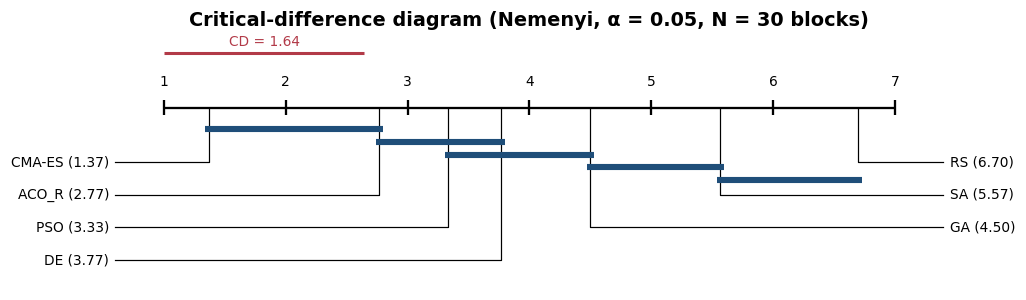

groups not significantly different (thick bars): [['CMA-ES', 'ACO_R'], ['ACO_R', 'PSO', 'DE'], ['PSO', 'DE', 'GA'], ['GA', 'SA'], ['SA', 'RS']]


In [11]:
def cd_diagram(avg_rank, names, CD, ax, title):
    k = len(names); o = np.argsort(avg_rank); r = avg_rank[o]
    ax.set_xlim(0.5, k + 0.5); ax.set_ylim(0.3, 1); ax.axis("off")
    ax.hlines(0.8, 1, k, color="k");
    for i in range(1, k + 1):
        ax.vlines(i, 0.78, 0.82, color="k"); ax.text(i, 0.86, str(i), ha="center", fontsize=9)
    ax.hlines(0.95, 1, 1 + CD, color=PALETTE["red"], lw=2); ax.text(1 + CD / 2, 0.97, f"CD = {CD:.2f}", ha="center", color=PALETTE["red"], fontsize=9)
    half = (k + 1) // 2
    for i, (ri, ni) in enumerate(zip(r, np.array(names)[o])):
        left = i < half; y = 0.65 - 0.09 * (i if left else k - 1 - i)
        xt = 0.6 if left else k + 0.4
        ax.plot([ri, ri, xt], [0.8, y, y], color="k", lw=0.8)
        ax.text(xt + (-0.05 if left else 0.05), y, f"{ni} ({ri:.2f})", ha="right" if left else "left", va="center", fontsize=9)
    # cliques: maximal runs of consecutive algorithms whose rank range is < CD
    cliques = []
    for i in range(k):
        j = i
        while j + 1 < k and r[j + 1] - r[i] < CD: j += 1
        if j > i and not any(a <= i and j <= b for a, b in cliques): cliques.append((i, j))
    for c, (i, j) in enumerate(cliques):
        yb = 0.74 - 0.035 * c
        ax.hlines(yb, r[i] - 0.03, r[j] + 0.03, color=PALETTE["blue"], lw=4)
    ax.set_title(title)
    return cliques

fig, ax = plt.subplots(figsize=(10, 3.0))
cliques = cd_diagram(avg_rank, names, CD, ax, f"Critical-difference diagram (Nemenyi, α = 0.05, N = {len(blocks)} blocks)")
savefig("w6_lab_cd_diagram.png"); plt.show()
print("groups not significantly different (thick bars):", [[names[order[t]] for t in range(i, j + 1)] for i, j in cliques])

**Reading the result.** Rank order and significance come from the printed output above; the CD diagram draws a bar
under groups of algorithms whose average ranks differ by less than CD, i.e. that the Nemenyi test cannot separate
with 30 blocks. Nemenyi is conservative (it controls all $k(k-1)/2$ comparisons); the Wilcoxon-Holm comparisons against the
best algorithm are more powerful for the question "is the winner really better than X?". Note what the statistics
*cannot* say: a significant difference over *this* suite, budget and dimension does not transfer to other budgets
(the fixed-budget graphs show rankings that change over time) nor to other function classes — the no-free-lunch
theorems (Wolpert & Macready 1997) guarantee that averaged over all functions every algorithm is equal.

**Budget sensitivity.** Recomputing the Friedman average ranks at smaller budgets makes the point quantitatively.

In [12]:
rank_at = {}
for b_ in [100, 500, 1000, B]:
    Yb = np.array([[max(on_grid(*traces[n, fn, s], [b_])[0], 1e-8) for n in names] for fn, s in blocks])
    rank_at[b_] = friedman_test(Yb)[2]
    print(f"budget {b_:5d}: " + ", ".join(f"{names[i]} {rank_at[b_][i]:.2f}" for i in np.argsort(rank_at[b_])))
top_changes = len({names[int(np.argmin(v))] for v in rank_at.values()})
print(f"number of distinct rank-1 algorithms across the four budgets: {top_changes}")

budget   100: PSO 1.75, CMA-ES 1.80, ACO_R 3.63, DE 4.45, GA 4.60, RS 4.90, SA 6.87
budget   500: CMA-ES 1.10, PSO 2.37, ACO_R 3.00, GA 4.33, DE 5.13, SA 5.53, RS 6.53
budget  1000: CMA-ES 1.03, PSO 2.87, ACO_R 2.93, GA 4.00, DE 4.97, SA 5.63, RS 6.57


budget  5000: CMA-ES 1.37, ACO_R 2.77, PSO 3.33, DE 3.77, GA 4.50, SA 5.57, RS 6.70
number of distinct rank-1 algorithms across the four budgets: 2


## 5. Reproducibility checklist for metaheuristic papers

Drawn from Bartz-Beielstein et al. (2020, *Benchmarking in optimization: best practice and open issues*), Hansen et al.
(2021, COCO), Demšar (2006), López-Ibáñez, Branke & Paquete (2021, *Reproducibility in evolutionary computation*, ACM TELO)
and the metaphor critique (Sörensen 2015):

1. **Algorithm described by mechanisms**, not metaphor: representation, variation distribution, selection/acceptance,
   memory update; relation to existing algorithms stated.
2. **All parameters reported**, including defaults, and **how** they were set (tuning method, tuning budget, tuning
   instances disjoint from test instances).
3. **Budgets in function evaluations**, equal for all competitors; wall-clock only as a secondary measure with hardware.
4. **Test functions shifted and rotated** (no centre or separability bias), several dimensions, instances generated
   from recorded seeds; real-world problems where possible.
5. **Baselines include** random search and a strong modern method (e.g. CMA-ES/IPOP, L-SHADE) with their recommended
   settings — not only weak or mis-tuned competitors.
6. **Independent runs** (≥ 15 per instance in serious studies), seeds reported, full traces archived.
7. **Both views**: fixed-target (ERT, runtime ECDF) and fixed-budget; anytime performance rather than a single budget.
8. **Statistics**: non-parametric tests suited to the design (Wilcoxon, Friedman + post-hoc), multiple-comparison
   correction (Holm), effect sizes, not only $p$-values; report negative results.
9. **Code and data released** (version-pinned environment), so that every number and figure can be regenerated.
10. **Scope of the claims** matches the experiment (budget, dimension, function class) — no-free-lunch applies.

**AI/ML connection.** The same discipline applies to comparing hyperparameter optimisers or RL algorithms: equal
budgets, many seeds, performance profiles and rank-based tests (Henderson et al. 2018 "Deep RL that matters";
Agarwal et al. 2021 on statistical precipices in RL evaluation) — and the same pitfalls of single-seed anecdotes.

## Key takeaways
- Benchmark on shifted–rotated instances with equal evaluation budgets and record full traces; conclusions are only
  valid for the budget/dimension/function class tested.
- Fixed-target measures (ERT, runtime ECDFs) are on a ratio scale and aggregate across functions; ERT is an exact,
  consistent estimator of the restart runtime (validated: ERT $\to1/p$ for geometric runtimes).
- Performance profiles show both speed ($\rho_s(1)$) and robustness ($\rho_s(\infty)$) at a glance.
- Friedman + Nemenyi (CD diagram) for many algorithms, Wilcoxon + Holm for comparisons with a control; our
  implementations agree with `scipy.stats` and with the published critical values.
- Rankings depend on the budget: report anytime performance, not a single number.

## Exercises
1. ★ Prove that ERT with censoring at $B$ is a consistent estimator of $1/p$ for geometric runtimes, and compute its
   expectation when only $n$ runs are made (hint: condition on the number of successes).
2. ★ Show that $\rho_s(1)$ summed over solvers is at least 1 (for problems solved by someone) and explain why ties
   make it larger. Why is the performance profile of a solver not independent of the *other* solvers in the comparison?
3. ★★ Derive the exact null distribution of Wilcoxon's $W^{+}$ by the subset-sum recursion used above, and its mean and
   variance. Show how ties change the variance.
4. ★★ Prove that Holm's procedure controls the family-wise error rate at level $\alpha$ under arbitrary dependence.
5. ★★ Add JADE and the $(1+1)$-ES from Notebook 2 to the comparison, rerun at $B=1000d$ with 10 instances, and redraw
   the CD diagram. Which conclusions change?
6. ★★★ Implement a bootstrap confidence band for the runtime ECDF (resample instances, not runs) and use it to decide
   whether the ECDFs of PSO and CMA-ES differ significantly at $t=100d$.